# Семинар №2

## <center>Fully-connected neural network`</center>

> **What is it?**
>    * a type of artificial neural network where the architecture is such that all the nodes, or neurons, in one layer are connected to the neurons in the next layer.
>    * algebraic representation (i.e., the formula) of a general single hidden-layer unit, also called a single layer unit for short, is quite simple: a linear combination of input passed through a nonlinear 'activation' function (which is often a simple elementary mathematical function):
$$f^{(1)}(x) = a(w_0^{(1)} + \sum w_ix_i)$$

>    * The left most layer is called the input layer, and the neurons within the layer are called input neurons
>    * The right most or output layer contains the output neurons (just one here). The middle layer is called a hidden layer, since the neurons in this layer are neither inputs nor outputs. We do not observe (directly) what goes out of this layer.
>    * as many neurons in the input layer than the number of explanatory/features variables; as many neurons in the output layer than the number of possible values for the response variable

![image.png](img.png)

### <center> How to train everything? </center>
>    * Import all libraries
>    * Upload your data -> put it into torch Dataset & Dataloader if required with specific batch size
>    * Create your model: either class of Sequential, depending on the task's complexity
>    * Define learning rate, optimizer, loss function, lr_scheduler (if needed)
>    * Run training by batches for the predefined number of epochs on the maintained share of data
>    * Regularly run inference to estimate the quality of model

**1. Libraries**

In [2]:
# Импортируем базовые библиотеки Python
import os  # библиотека для работы с операционной системой и файловыми путями
import pandas as pd  # библиотека для работы с табличными данными
import matplotlib.pyplot as plt  # библиотека для визуализации и построения графиков

# Импортируем основную библиотеку PyTorch для глубокого обучения
import torch  # главный модуль библиотеки torch с основными функциями для работы с тензорами

# Импортируем модуль для создания нейронных сетей
from torch import nn  # модуль, содержащий слои нейронных сетей (Linear, Conv2d и т.д.)

# Импортируем классы для работы с данными
from torch.utils.data import Dataset  # базовый класс для создания пользовательских наборов данных
from torchvision import datasets  # модуль с готовыми популярными наборами данных (MNIST, CIFAR и др.)
from torchvision.transforms import ToTensor  # преобразование изображений в тензоры PyTorch
from torchvision.io import read_image  # функция для чтения изображений и преобразования пикселей в тензор
from torch.utils.data import DataLoader  # класс для загрузки данных пакетами (батчами) при обучении модели

**2. Dataset**

In [3]:
# Загружаем тренировочный набор данных FashionMNIST

training_data = datasets.FashionMNIST(
    root="data",  # путь к папке, где будут храниться тренировочные и тестовые данные
    train=True,  # указываем, что нужен тренировочный набор данных (если False - то тестовый)
    download=True,  # автоматически скачиваем данные из интернета, если их нет в папке root
    transform=ToTensor()  # преобразуем изображения в тензоры PyTorch для дальнейшей работы
)

# Загружаем тестовый набор данных FashionMNIST
test_data = datasets.FashionMNIST(
    root="data",  # путь к папке с данными
    train=False,  # указываем, что нужен тестовый набор данных
    download=True,  # автоматически скачиваем данные, если необходимо
    transform=ToTensor()  # преобразуем изображения в тензоры
)

In [4]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [5]:
img, true_label = training_data[77]  # вызываем FashionMNIST.__getitem__(77)
print(f'Истинный класс картинки: {true_label}')

Истинный класс картинки: 6


In [6]:
img.shape

torch.Size([1, 28, 28])

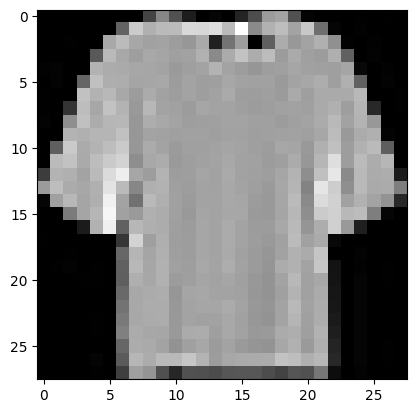

In [7]:
plt.imshow(img[0], cmap='gray')

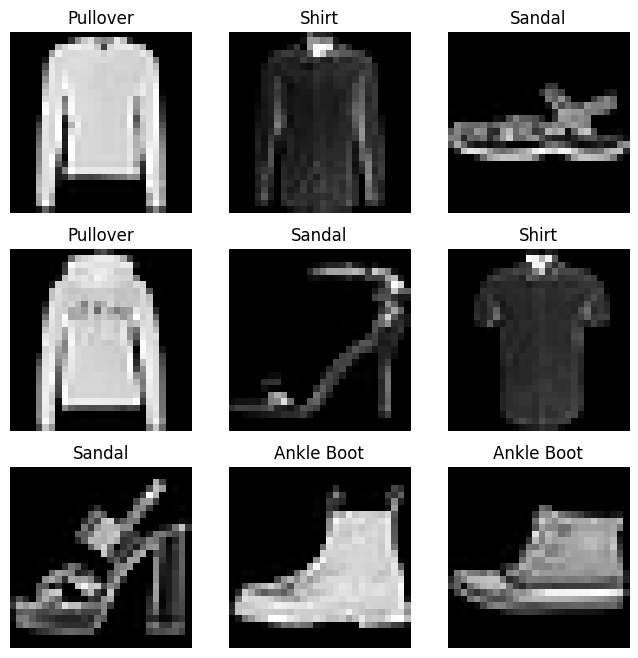

In [8]:
# Визуализация примеров из набора данных FashionMNIST

# Создаем словарь для сопоставления числовых меток (0-9) с названиями классов одежды
labels_map = {
    0: "T-Shirt",      # футболка
    1: "Trouser",      # брюки
    2: "Pullover",     # пуловер
    3: "Dress",        # платье
    4: "Coat",         # пальто
    5: "Sandal",       # сандалии
    6: "Shirt",        # рубашка
    7: "Sneaker",      # кроссовки
    8: "Bag",          # сумка
    9: "Ankle Boot",   # ботинки
}

# Создаем объект figure (фигуру) для визуализации размером 8x8 дюймов
figure = plt.figure(figsize=(8, 8))

# Задаем количество столбцов и строк для сетки изображений (3x3 = 9 изображений)
cols, rows = 3, 3

# Проходим по каждой позиции в сетке (от 1 до 9)
for i in range(1, cols * rows + 1):
    # Генерируем случайный индекс от 0 до размера тренировочного набора
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    
    # Получаем изображение и его метку по случайному индексу
    img, label = training_data[sample_idx]
    
    # Добавляем подграфик (ячейку) в сетку на позиции i
    figure.add_subplot(rows, cols, i)
    
    # Устанавливаем заголовок подграфика - название класса одежды
    plt.title(labels_map[label])
    
    # Отключаем отображение осей координат для более чистого вида
    plt.axis("off")
    
    # Отображаем изображение: squeeze() убирает лишние размерности, cmap="gray" задает черно-белую цветовую схему
    plt.imshow(img.squeeze(), cmap="gray")

# Отображаем всю фигуру с 9 изображениями
plt.show()

In [9]:
our_list = list([1, 2, 3])
our_list.append

<function list.append(object, /)>

In [10]:
class Animal:

    def __init__(self, user_weight, user_age, user_name, user_food):  # метод создания нового объекта
        self.weight = user_weight
        self.age = user_age
        self.name = user_name
        self.food = user_food

    def eat(self):
        print(f'Я съел {self.food}! Я больше не голоден!')

    def sleep(self, hours):
        print(f'Я поспал {hours} часов! Я хочу есть!')
        eat()

class Bird(Animal):  # показываем, что наследуем методы и атрибуты класса Animal

    def __init__(self, user_weight, user_age, user_name, user_food):  # метод создания нового объекта
        super().__init__(user_weight, user_age, user_name, user_food)  # Animal.__init__, инициализируем родительский класс
        self.is_flying = False

    def fly(self, distance):
        if self.is_flying == True:
            print(f'Я налетался, уже пролетел {distance} км!')
            self.is_flying = False
        else:
            print(f'Хочу полетать еще {distance} км!')
            self.is_flying = True


lion = Animal(60, 3, 'Симба', 'мясо') # вызываем Animal.__init__(user_weight, user_age, user_name, user_food)
zebra = Animal(40, 5, 'Мартин', 'траву')

In [11]:
bear_1 = Animal(100, 2, 'Мишка', 'мед')
bear_2 = Animal(100, 2, 'Мишка', 'мед')

In [12]:
soroka = Bird(5, 3, 'Белобока', 'зерно')
soroka.age, soroka.name, soroka.is_flying

(3, 'Белобока', False)

In [13]:
soroka.eat()

Я съел зерно! Я больше не голоден!


In [14]:
soroka.fly(10)

Хочу полетать еще 10 км!


In [15]:
soroka.is_flying

True

In [16]:
# Создаем пользовательский класс для работы с набором данных изображений
class CustomImageDataset(Dataset):  # наследуем базовому классу torch.utils.data.Dataset
    
    # Метод инициализации класса - выполняется при создании объекта
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        # annotations_file - путь к CSV-файлу с аннотациями (имена файлов и метки)
        self.img_labels = pd.read_csv(annotations_file)
        
        # img_dir - путь к папке с изображениями
        self.img_dir = img_dir
        
        # transform - преобразования, которые применяются к изображениям (например, ресайз, нормализация)
        self.transform = transform
        
        # target_transform - преобразования, которые применяются к меткам (например, one-hot encoding)
        self.target_transform = target_transform
    
    # Метод возвращает общее количество элементов в наборе данных
    def __len__(self):
        return len(self.img_labels)
    
    # Метод получает один элемент данных по индексу idx
    def __getitem__(self, idx):
        # Создаем полный путь к изображению: объединяем папку img_dir с именем файла из первого столбца CSV
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        
        # Загружаем изображение и преобразуем его в тензор
        image = read_image(img_path)
        
        # Получаем метку класса из второго столбца CSV
        label = self.img_labels.iloc[idx, 1]
        
        # Если заданы преобразования для изображения - применяем их
        if self.transform:
            image = self.transform(image)
        
        # Если заданы преобразования для метки - применяем их
        if self.target_transform:
            label = self.target_transform(label)
        
        # Возвращаем кортеж из изображения и его метки
        return image, label

In [17]:
img, label = training_data[77]  # training_data.__getitem__(77)

In [18]:
len(training_data)  # training_data.__len__()

60000

**3. Dataloader**

>   * The Dataset retrieves our dataset’s features and labels one sample at a time. 
>   * While training a model, we typically want to pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.
>   * DataLoader is an iterable that abstracts this complexity for us in an easy API

In [19]:
BATCH_SIZE = 64  # гиперпараметр

# Dataloader принимает датасет и выдает из него при каждом вызове BATCH_SIZE объектов
# На каждый датасет (train или test) свой загрузчик DataLoader

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)  # перемешиваем для обучения
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)  # не перемешиваем для теста

In [20]:
train_dataloader

In [21]:
zip([1, 2, 3], [4, 5, 6])

In [22]:
for letter in 'abcde':  # letter - итератор
    print(letter)

# итератор - переменная, которая бежит по некоторой последовательности
# итератор знает только где он сейчас и как перейти к следующему
# чтобы перейти к следующему нужно либо вызвать цикл for, либо вызвать функцию next

a
b
c
d
e


In [23]:
map_iterator = map(str, [1, 2, 3])
next(map_iterator)

'1'

In [24]:
next(map_iterator)

'2'

In [25]:
next(map_iterator)

'3'

In [26]:
next(map_iterator)

StopIteration: 

In [27]:
iterator_step = next(iter(train_dataloader))
iterator_step[0].shape  

# (B, C, H, W)
# B - batch_size, кол-во картинок в батче
# C - channels, кол-во каналов
# H - height, высота картинок
# W - width, ширина картинок

torch.Size([64, 1, 28, 28])

In [28]:
iterator_step[1]  # labels, правильные ответы для картинок в батче

tensor([8, 0, 7, 1, 4, 9, 0, 7, 5, 2, 4, 5, 4, 2, 3, 8, 7, 4, 7, 5, 7, 7, 6, 8,
        3, 0, 5, 3, 5, 2, 8, 8, 3, 9, 0, 0, 3, 3, 3, 0, 3, 9, 6, 8, 5, 0, 5, 9,
        3, 3, 1, 6, 4, 9, 6, 1, 4, 9, 0, 9, 8, 0, 0, 3])

>   * We have loaded that dataset into the DataLoader and can iterate through the dataset as needed. 
>   * Each iteration below returns a batch of train_features and train_labels (containing batch_size=64 features and labels respectively). 
>   * Because we specified shuffle=True, after we iterate over all batches the data is shuffled

In [29]:
next(iter(train_dataloader))[1].shape

torch.Size([64])

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


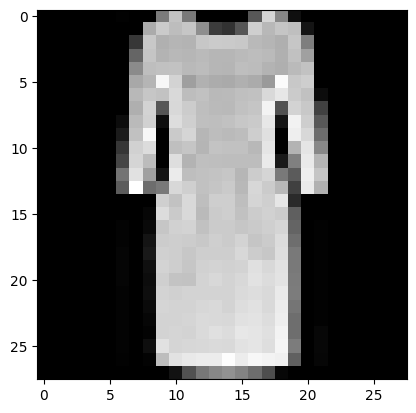

Label: 3


In [30]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

**4. Neural network**
>
>    * The torch.nn namespace provides all the building blocks you need to build your own neural network. 
>    * Every module in PyTorch subclasses the nn.Module. A neural network is a module itself that consists of other modules (layers). 
>    * This nested structure allows for building and managing complex architectures easily.

>    * We define our neural network by subclassing nn.Module, and initialize the neural network layers in __init__. Every nn.Module subclass implements the operations on input data in the forward method.
>
>    * We create an instance of NeuralNetwork, and move it to the device

In [31]:
linear_1 = nn.Linear(10, 5)
x = torch.randn(10)

linear_1(x) # запускаем forward один линейный слой

tensor([-0.0778,  0.1371,  1.1246,  0.5425,  1.0374], grad_fn=<ViewBackward0>)

In [32]:
# nn.Sequential - вроде контейнера, последовательно вызывает слои внутри себя

model = nn.Sequential( 
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

x = torch.randn(10)

model(x) # запускаем forward набор слоев

tensor([0.4278], grad_fn=<ViewBackward0>)

In [ ]:
nn.Linear(28*28, 100) -> nn.ReLU() -> nn.BatchNorm1d(100) -> nn.Dropout(0.2) -> nn.Linear(100, 10) -> предсказания

In [ ]:
model = nn.Sequential(
    nn.Linear(28*28, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Dropout(0.2),
    nn.Linear(100, 10)
)

In [47]:
class NeuralNetwork(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # для выпрямления картинки
        self.layers = nn.Sequential(  # набор слоев
            nn.Linear(28*28, 100),
            nn.ReLU(),
            nn.BatchNorm1d(100),
            nn.Dropout(0.2),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        x = self.flatten(x)  # выпрямили картинки
        result = self.layers(x)  # посчитали предсказание
        return result  # вернули ответы

In [48]:
# device = ("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork()  # .to(device)

In [49]:
model.layers[0].weight

Parameter containing:
tensor([[ 0.0334, -0.0114,  0.0271,  ..., -0.0060, -0.0003, -0.0068],
        [ 0.0093,  0.0322,  0.0061,  ...,  0.0120, -0.0333, -0.0078],
        [ 0.0015,  0.0128,  0.0332,  ..., -0.0045,  0.0229,  0.0321],
        ...,
        [-0.0122,  0.0286, -0.0041,  ..., -0.0179,  0.0313, -0.0265],
        [ 0.0022,  0.0154,  0.0061,  ..., -0.0322, -0.0064, -0.0133],
        [ 0.0017,  0.0270,  0.0031,  ...,  0.0044,  0.0350,  0.0045]],
       requires_grad=True)

In [50]:
for data in train_dataloader:
    print(data)
    break

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.1529, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.2039, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  .

In [51]:
data[0].shape # даталоадер вернул батч картинок, 64 картинки по 1 каналу 28 на 28

torch.Size([64, 1, 28, 28])

In [52]:
data[1]  # и ответы для этих 64 картинок, y_true - классы

tensor([9, 2, 2, 8, 8, 5, 9, 5, 6, 4, 8, 9, 4, 9, 7, 9, 9, 9, 9, 9, 5, 7, 8, 7,
        8, 4, 2, 7, 3, 6, 2, 5, 9, 9, 9, 7, 9, 1, 1, 7, 1, 2, 2, 6, 7, 7, 3, 6,
        7, 7, 1, 2, 3, 9, 3, 6, 4, 5, 6, 2, 1, 9, 0, 0])

In [57]:
result = model(data[0])
result.shape  # для 64 картинок получили на каждую по 10 предсказаний, по одному на каждый возможный класс

torch.Size([64, 10])

In [98]:
input_image = next(iter(train_dataloader))[0]

flatten = nn.Flatten()
flat_image = flatten(input_image)
print('Size before flatten\t', input_image.size())
print('Size after flatten\t', flat_image.size())

layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print('Size after hidden layer\t', hidden1.size())

print(f"\nBefore ReLU:\n {hidden1[0]}\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU:\n {hidden1[0]}")

Size before flatten	 torch.Size([64, 1, 28, 28])
Size after flatten	 torch.Size([64, 784])
Size after hidden layer	 torch.Size([64, 20])

Before ReLU:
 tensor([-0.3162,  0.2639, -0.1279, -0.0225,  0.0980,  0.0338, -0.0627,  0.2498,
        -0.1796, -0.1919, -0.0366,  0.0467, -0.0343,  0.0635, -0.0124, -0.1928,
         0.1986,  0.0442,  0.2163,  0.0785], grad_fn=<SelectBackward0>)

After ReLU:
 tensor([0.0000, 0.2639, 0.0000, 0.0000, 0.0980, 0.0338, 0.0000, 0.2498, 0.0000,
        0.0000, 0.0000, 0.0467, 0.0000, 0.0635, 0.0000, 0.0000, 0.1986, 0.0442,
        0.2163, 0.0785], grad_fn=<SelectBackward0>)


>   * The last linear layer of the neural network returns logits - raw values in [$-\infty,\ \infty$], which are passed to the nn.Softmax module. The logits are scaled to values [0, 1] representing the model’s predicted probabilities for each class.

In [109]:
seq_modules = nn.Sequential(
    flatten,
    nn.Linear(in_features=28*28*3, out_features=20),
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(1,3,28,28)
logits = seq_modules(input_image)

softmax = nn.Softmax(dim=1)
pred_prob = softmax(logits)

**5. Hyperparameters**

In [58]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

loss_fn = nn.CrossEntropyLoss() # = LogSoftmax + NLL
model = NeuralNetwork() # .to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

**6. Training & Inference**

In [61]:
lst = ['a', 'b', 'c']
for i, value in enumerate(lst):
    print(i)

0
1
2


In [ ]:
for data in dataloader -> в data лежит батч картинок и ответы для этих картинок

for i, data in enumerate(dataloader) -> ловим индекс батча по порядку и data

In [66]:
train_loss = []  # список для записи ошибок 

for batch_idx, data in enumerate(train_dataloader):  # итерируемся по индексам и батчам

    X = data[0] # все картинки в батче, размер=(64 картинки, 1 канал, 28 на 28)
    y = data[1] # ответ на каждую картинку
    
    # Compute prediction and loss
    pred = model(X)  # считаем предскзания модели (автоматически вызывается forward)
    # всего у нас 10 классов
    # на каждую картинку по 10 предскзааний (для каждого класса)
    # выигрывает класс с наибольшим значением предсказания
    # всего 64 на 10 в pred лежит
    
    loss = loss_fn(pred, y)  # считаем значение ошибки через loss_fn = CrossEntropyLoss

    # Backpropagation
    loss.backward()  # тензор, полученный из функции потерь, от которого запускается подсчет производных
    # тут мы посчитали производные для всех тензоров, участвовавших в появлении loss тензора
    
    optimizer.step() 
    # optimizer - это объект, отвечающий за обновление параметров, переданных при создании
    # через производные, полученные после loss.backward


    optimizer.zero_grad()
    # обнуление градиентов у всех параметров, за которые отвечает оптимизатор Adam

    if batch_idx % 100 == 0:
        train_loss.append(loss.item())
        loss, current = loss.item(), (batch_idx + 1) * len(X)
        print(f"loss: {loss:>7f}")

loss: 1.577366
loss: 0.583752
loss: 0.531111
loss: 0.766844
loss: 0.487504
loss: 0.653987
loss: 0.410495
loss: 0.344652
loss: 0.499771
loss: 0.392670


In [125]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    train_loss = []
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            train_loss.append(loss.item())
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return train_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss

In [130]:
train_data, test_data = [], []
for t in range(1):
    print(f"Epoch {t+1}\n-------------------------------")
    train_data.append(train_loop(train_dataloader, model, loss_fn, optimizer))
    test_data.append(test_loop(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
loss: 0.255406  [   64/60000]
loss: 0.204462  [ 6464/60000]
loss: 0.384568  [12864/60000]
loss: 0.488016  [19264/60000]
loss: 0.236175  [25664/60000]
loss: 0.389148  [32064/60000]
loss: 0.411335  [38464/60000]
loss: 0.296573  [44864/60000]
loss: 0.317653  [51264/60000]
loss: 0.350205  [57664/60000]
Test Error: 
 Accuracy: 85.9%, Avg loss: 0.383816 

Done!


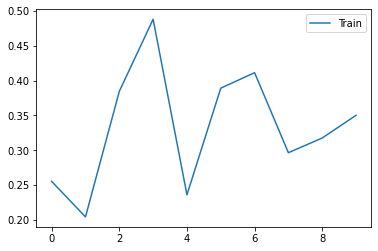

In [137]:
plt.plot(train_data[0], label='Train')
plt.legend()
plt.show()

**7. Save model**

In [140]:
# Сохраняем веса обученной модели в файл 'model_weights.pth'
# state_dict() возвращает словарь с параметрами модели (веса и смещения всех слоев)
# Этот способ является предпочтительным, так как сохраняет только параметры, а не всю структуру
torch.save(model.state_dict(), 'model_weights.pth')

# Альтернативный способ: сохранение всей модели целиком
# Этот метод сохраняет и структуру, и параметры, но менее гибкий
#torch.save(model, 'model.pth')

In [141]:
# Создаем новую экземпляр модели NeuralNetwork со случайными весами
# Это необученная модель, чтобы продемонстрировать разницу в качестве
model = NeuralNetwork()

# Запускаем тестирование необученной модели на тестовых данных
# Ожидаем низкую точность (~10%), так как веса случайные
test_loop(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 13.8%, Avg loss: 2.303292 



2.303292187915486

In [142]:
# Загружаем сохраненные веса из файла 'model_weights.pth' в нашу модель
# load_state_dict() подгружает параметры в существующую структуру модели
model.load_state_dict(torch.load('model_weights.pth'))

# Тестируем модель с загруженными весами
# Ожидаем высокую точность (~85%), так как веса обученные
test_loop(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 85.9%, Avg loss: 0.382975 



0.3829754857690471

**8. Enhance model**

In [146]:
# Создаем слой Dropout с вероятностью отключения нейронов 40% (p=0.4)
# Dropout - это метод регуляризации, который помогает бороться с переобучением
dropout = nn.Dropout(p=0.4)

# Создаем случайный тензор 3x7 со значениями от 0 до 1
x = torch.rand(3, 7)

# Переводим dropout в режим обучения (training mode)
# В этом режиме нейроны будут случайно отключаться
dropout.train()

# Выводим исходный тензор
print('x', x, '\n')

# Выводим тензор, разделенный на 0.6 (1-p) для сравнения
# Dropout масштабирует оставшиеся значения на 1/(1-p), чтобы сохранить ожидаемую сумму
print('x/0.6', x / 0.6, '\n')

# Применяем dropout 3 раза - каждый раз отключаются разные нейроны
# Нулевые значения - это отключенные нейроны, остальные масштабированы
for _ in range(3):
    print(dropout(x))

# Переводим dropout в режим тестирования (evaluation mode)
# В этом режиме dropout не применяется - все нейроны активны
dropout.eval()

# Проверяем, что в режиме eval тензор не изменяется
print(dropout(x))

x tensor([[0.8368, 0.7051, 0.7581, 0.6984, 0.8534, 0.4322, 0.5123],
        [0.6499, 0.0043, 0.6137, 0.7601, 0.2519, 0.0193, 0.9535],
        [0.3489, 0.5630, 0.3931, 0.3955, 0.0222, 0.0844, 0.2971]]) 

x/0.6 tensor([[1.3946, 1.1752, 1.2635, 1.1641, 1.4223, 0.7203, 0.8539],
        [1.0832, 0.0071, 1.0228, 1.2668, 0.4199, 0.0322, 1.5891],
        [0.5816, 0.9383, 0.6552, 0.6591, 0.0371, 0.1407, 0.4952]]) 

tensor([[1.3946, 0.0000, 0.0000, 1.1641, 0.0000, 0.0000, 0.8539],
        [0.0000, 0.0071, 1.0228, 1.2668, 0.0000, 0.0322, 1.5891],
        [0.5816, 0.9383, 0.6552, 0.0000, 0.0371, 0.0000, 0.4952]])
tensor([[1.3946, 1.1752, 1.2635, 0.0000, 1.4223, 0.0000, 0.8539],
        [1.0832, 0.0000, 0.0000, 1.2668, 0.0000, 0.0322, 1.5891],
        [0.5816, 0.9383, 0.6552, 0.0000, 0.0000, 0.1407, 0.0000]])
tensor([[0.0000, 1.1752, 1.2635, 1.1641, 0.0000, 0.0000, 0.0000],
        [1.0832, 0.0071, 1.0228, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.9383, 0.0000, 0.6591, 0.0371, 0.0000, 0.4

In [ ]:
# Создаем слой Batch Normalization для 7 признаков
# BatchNorm1d нормализует выход по батчу, ускоряя обучение и стабилизируя градиенты
batch_norm = nn.BatchNorm1d(num_features=7)

# Применяем batch normalization к тензору x
# Batch normalization вычисляет среднее и дисперсию, затем нормализует каждый признак
batch_norm(x)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 5 

# 1. Берём предобученную модель (пример: resnet18)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. Замораживаем все слои 
for param in model.parameters():
    param.requires_grad = False

# 3. Узнаём размер входа в последнюю FC и переопределяем голову
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# 4. Оптимизатор только по новой голове
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
